In [1]:
#import pandas and read in the NYPD arrest dataset

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()

filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

Saving NYPD_Arrest_Data_(Year_to_Date)_20260407.csv to NYPD_Arrest_Data_(Year_to_Date)_20260407.csv


In [2]:
#First look at the dataset

df.head()

,ARREST_KEY,ARREST_DATE,PD_CD,PD_DESC,KY_CD,OFNS_DESC,LAW_CODE,LAW_CAT_CD,ARREST_BORO,ARREST_PRECINCT,JURISDICTION_CODE,AGE_GROUP,PERP_SEX,PERP_RACE,X_COORD_CD,Y_COORD_CD,Latitude,Longitude,Location
0,299201470,01/10/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,Q,110,0,25-44,F,WHITE,1017105,210917,40.745543,-73.881427,POINT (-73.881427 40.745543)
1,299351927,01/13/2025,105,STRANGULATION 1ST,106.0,FELONY ASSAULT,PL 1211200,F,S,120,0,25-44,M,BLACK,962808,174275,40.645005,-74.077265,POINT (-74.077265 40.645005)
2,299366743,01/13/2025,157,RAPE 1,104.0,RAPE,PL 130351A,F,B,46,0,25-44,M,BLACK HISPANIC,1011755,250279,40.853598,-73.900577,POINT (-73.9005768807295 40.8535983673823)
3,300990163,02/12/2025,153,RAPE 3,104.0,RAPE,PL 1302504,F,K,77,0,(null),(null),BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)
4,301010124,02/12/2025,157,RAPE 1,104.0,RAPE,PL 130353A,F,K,77,0,25-44,M,BLACK,1003509,185018,40.674496,-73.930571,POINT (-73.9305713255961 40.6744956865259)


In [3]:
#check columns and data types

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 278953 entries, 0 to 278952
Data columns (total 19 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   ARREST_KEY         278953 non-null  int64  
 1   ARREST_DATE        278953 non-null  object 
 2   PD_CD              278953 non-null  int64  
 3   PD_DESC            278953 non-null  object 
 4   KY_CD              278930 non-null  float64
 5   OFNS_DESC          278953 non-null  object 
 6   LAW_CODE           278953 non-null  object 
 7   LAW_CAT_CD         277479 non-null  object 
 8   ARREST_BORO        278953 non-null  object 
 9   ARREST_PRECINCT    278953 non-null  int64  
 10  JURISDICTION_CODE  278953 non-null  int64  
 11  AGE_GROUP          278953 non-null  object 
 12  PERP_SEX           278953 non-null  object 
 13  PERP_RACE          278953 non-null  object 
 14  X_COORD_CD         278953 non-null  int64  
 15  Y_COORD_CD         278953 non-null  int64  
 16  La

In [4]:
#Cleaning task: the borough column uses single letters which are hard to read
#decode them into full names so the analysis is easier to follow

boro_map = {'B': 'Bronx', 'K': 'Brooklyn', 'M': 'Manhattan', 'Q': 'Queens', 'S': 'Staten Island'}
df['BOROUGH'] = df['ARREST_BORO'].map(boro_map)

df['BOROUGH'].value_counts()

,count
BOROUGH,
Brooklyn,79882
Manhattan,66448
Bronx,62833
Queens,58083
Staten Island,11707


In [5]:
#Cleaning task: drop rows with missing offense level since we'll use it later

df.dropna(subset=['LAW_CAT_CD'], inplace=True)
df.shape

(277479, 20)

In [6]:
#Pick a neighborhood/district as the initial comparison point: I picked the Bronx
#Pick a second entity to compare it to: Manhattan
#Pick a feature/column to study: OFNS_DESC (offense category)

bronx = df[df['BOROUGH'] == 'Bronx']
manhattan = df[df['BOROUGH'] == 'Manhattan']

print('Bronx arrests:', len(bronx))
print('Manhattan arrests:', len(manhattan))

Bronx arrests: 62463
Manhattan arrests: 65715


In [7]:
#Descriptive statistics: top 5 offense categories in each borough

print('Top 5 offenses - Bronx')
print(bronx['OFNS_DESC'].value_counts().head(5))
print()
print('Top 5 offenses - Manhattan')
print(manhattan['OFNS_DESC'].value_counts().head(5))

Top 5 offenses - Bronx
OFNS_DESC
ASSAULT 3 & RELATED OFFENSES       10306
FELONY ASSAULT                      6379
DANGEROUS DRUGS                     5172
OTHER OFFENSES RELATED TO THEFT     4367
VEHICLE AND TRAFFIC LAWS            4009
Name: count, dtype: int64

Top 5 offenses - Manhattan
OFNS_DESC
PETIT LARCENY                      11045
ASSAULT 3 & RELATED OFFENSES        7723
DANGEROUS DRUGS                     6336
OTHER OFFENSES RELATED TO THEFT     4409
FELONY ASSAULT                      4049
Name: count, dtype: int64


In [8]:
#Descriptive statistics: felony vs misdemeanor breakdown for each borough

level_map = {'F': 'Felony', 'M': 'Misdemeanor', 'V': 'Violation', 'I': 'Infraction'}

borough_comparison = pd.DataFrame({
    'Bronx': (bronx['LAW_CAT_CD'].map(level_map).value_counts(normalize=True) * 100).round(1),
    'Manhattan': (manhattan['LAW_CAT_CD'].map(level_map).value_counts(normalize=True) * 100).round(1)
})

print(borough_comparison)

             Bronx  Manhattan
LAW_CAT_CD                   
Misdemeanor   59.3       60.3
Felony        40.2       38.5
Violation      0.4        1.1
Infraction     0.1        0.1


In [9]:
#build a dataframe of the top 10 offenses across both boroughs to use in the plot

top_offenses = pd.concat([bronx, manhattan])['OFNS_DESC'].value_counts().head(10).index

compare = pd.DataFrame({
    'Offense': top_offenses,
    'Bronx': [bronx['OFNS_DESC'].value_counts().get(o, 0) for o in top_offenses],
    'Manhattan': [manhattan['OFNS_DESC'].value_counts().get(o, 0) for o in top_offenses]
})

compare_melted = compare.melt(id_vars='Offense', var_name='Borough', value_name='Arrests')
compare_melted

,Offense,Borough,Arrests
0,ASSAULT 3 & RELATED OFFENSES,Bronx,10306
1,PETIT LARCENY,Bronx,3840
2,DANGEROUS DRUGS,Bronx,5172
3,FELONY ASSAULT,Bronx,6379
4,OTHER OFFENSES RELATED TO THEFT,Bronx,4367
5,MISCELLANEOUS PENAL LAW,Bronx,3459
6,VEHICLE AND TRAFFIC LAWS,Bronx,4009
7,GRAND LARCENY,Bronx,1696
8,ROBBERY,Bronx,3012
9,CRIMINAL MISCHIEF & RELATED OF,Bronx,2794


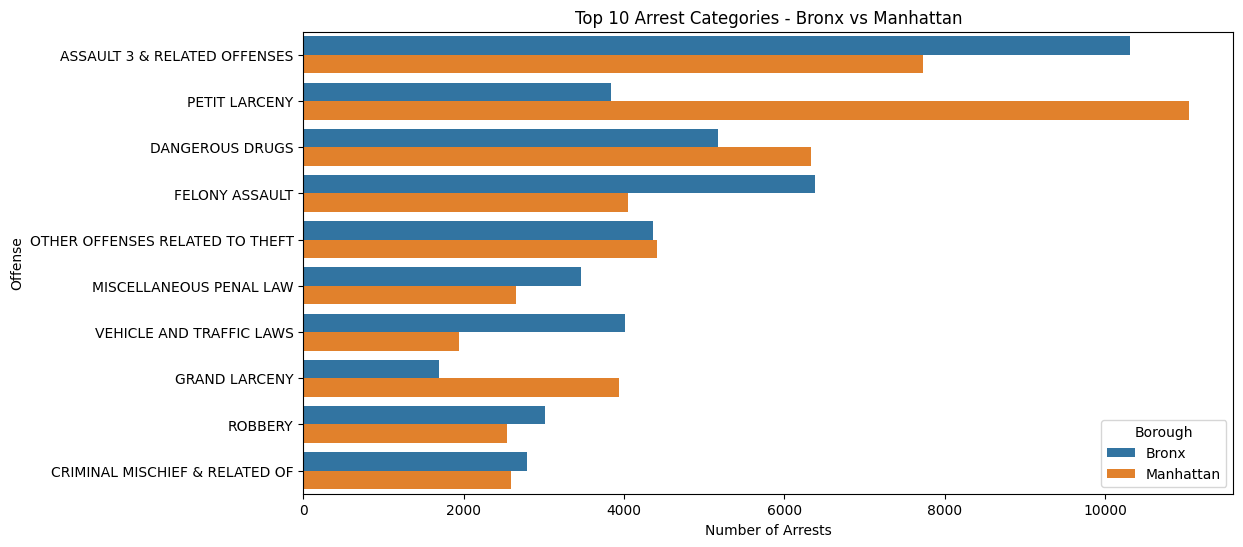

In [10]:
#Visualization: top 10 arrest categories - Bronx vs Manhattan

plt.figure(figsize=(12,6))

sns.barplot(
    data=compare_melted,
    y='Offense',
    x='Arrests',
    hue='Borough'
)

plt.title('Top 10 Arrest Categories - Bronx vs Manhattan')
plt.xlabel('Number of Arrests')
plt.ylabel('Offense')

plt.show()

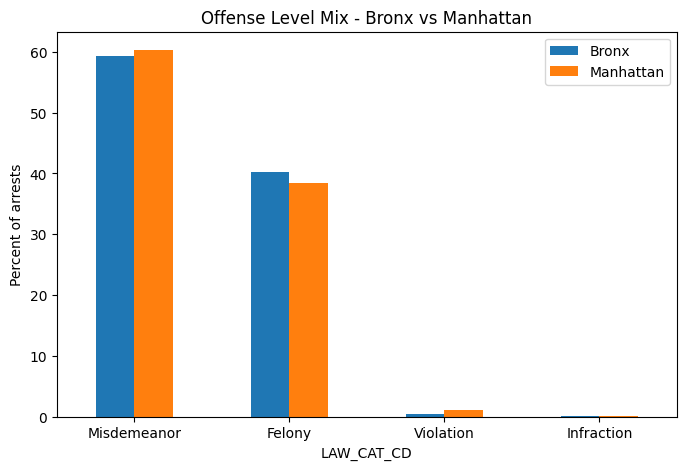

In [11]:
#Visualization: felony vs misdemeanor mix side by side

borough_comparison.plot(kind='bar', figsize=(8,5))
plt.title('Offense Level Mix - Bronx vs Manhattan')
plt.ylabel('Percent of arrests')
plt.xticks(rotation=0)
plt.show()

This data shows that the Bronx and Manhattan have almost the same total number of arrests in 2025, but the type of crime is very different. Manhattan is dominated by larceny which is property crime like shoplifting and theft, while the Bronx is dominated by assault which is violent crime. The Bronx also has a slightly higher share of felony arrests than Manhattan. So even though the overall arrest counts look similar, Manhattan has more of a property crime problem and the Bronx has more of a violence problem.